# Display Test Accuracy

In [51]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat

from matplotlib import pyplot as plt
from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

In [52]:
def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test) 


                                        if os.path.exists(event_dir):
                                            # print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, 
                                                "availability": av,
                                                "alpha": a, 
                                                "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

In [53]:
# config = ExperimentConfig(
#     base_path=os.path.join("..", "logs"),
#     experiment="mnist",
#     seeds=["42", "78", "84"],
#     algorithms=["fedavg", "fedvarp"],
#     events=["global"],
#     lr_list=["1e-1", "5e-2", "1e-2", "1e-3", "1e-4"],
#     alphas=["0.1"],
#     n_clients_list=["7"],
#     availabilities=list(
#         "gaussian-corr-ft-35 gaussian-corr-ft-50 gaussian-uncorr-ft-35 gaussian-uncorr-ft-50 gp-35-tcsc-10ft-2 gp-35-tusc-10ft-2 gp-50-tcsc-10ft-2 gp-50-tusc-10ft-2 gp-20304050607080-tcsu-10ft gp-20304050607080-tusu-10ft gp-25255050507575-tcsu-10ft gp-25255050507575-tusu-10ft".split(
#             " "
#         )
#     ),
#     n_rounds="100",
#     participations=["known"],
#     biased_list=["2"],
#     train_test="train",
# )

lrs=["5e-2", "1e-2", "1e-3"]
lrs=["5e-2"]

availabilities=[
# "gp100-50-tusu-10ft", 
# "gp100-50-tcsc-10ft", 
# "gp100-50-tcsu-10ft", 
# "gp100-35-tusu-10ft", 
# "gp100-35-tcsc-10ft", 
# "gp100-35-tcsu-10ft", 
# "gp100-25255050507575-tcsu-10ft", 
# "gp100-25255050507575-tusu-10ft", 
# "gp100-20304050607080-tcsu-10ft", 
# "gp100-20304050607080-tusu-10ft",
# "gp100-12202835425057-tcsu-10ft", 
# "gp100-12202835425057-tusu-10ft", 
# "gp100-18183535355252-tcsu-10ft", 
# "gp100-18183535355252-tusu-10ft"
# "gp100-50-tusu", 
# "gp100-50-tcsc", 
# "gp100-50-tcsu", 
"gp100-35-tusu", 
"gp100-35-tcsc", 
"gp100-35-tcsu", 
# "gp100-25255050507575-tcsu", 
# "gp100-25255050507575-tusu", 
# "gp100-20304050607080-tcsu", 
# "gp100-20304050607080-tusu",
"gp100-12202835425057-tcsu", 
"gp100-12202835425057-tusu", 
"gp100-18183535355252-tcsu", 
"gp100-18183535355252-tusu"
]
availabilities="alphaF50-199sl-1cb-3ft alphaF50-199sl-2cb-3ft alphaF50-197sl-3cb-3ft alphaF50-197sl-4cb-3ft alphaF50-197sl-5cb-3ft alphaF50-197sl-6cb-3ft alphaF50-196sl-7cb-3ft alphaF50-197sl-8cb-3ft alphaF50-197sl-9cb-3ft alphaF50-197sl-10cb-3ft alphaF50-196sl-11cb-3ft" # list of availability matrices


main_folder = 'correlation_experiments_100rounds'
config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="mnist_sp", seeds=["84"],
                          algorithms=["fedavg"], events=["global"],
                        #   lr_list=["1e-1", "5e-2", "1e-2", "5e-3", "1e-3"], alphas=["0.25"], n_clients_list=["7"],
                          lr_list=lrs, alphas=["0.5"], n_clients_list=["7"],
                          availabilities=availabilities.split(),
                          n_rounds="50", participations=["known"], biased_list=["2"], train_test="train")


results_df = get_exp_stats(config)

results_df


,algorithm,availability,alpha,participation,max_test_accuracy,final_test_accuracy,test_accuracy,seed,lr,event,n_clients,biased
0,fedavg,alphaF50-199sl-1cb-3ft,0.5,known,99.140000,99.110001,"[0.06729999929666519, 0.717199981212616, 0.289...",84,5e-2,global,7,2
1,fedavg,alphaF50-199sl-2cb-3ft,0.5,known,99.000001,98.989999,"[0.06729999929666519, 0.7106999754905701, 0.19...",84,5e-2,global,7,2
2,fedavg,alphaF50-197sl-3cb-3ft,0.5,known,99.040002,99.040002,"[0.06729999929666519, 0.6657000184059143, 0.75...",84,5e-2,global,7,2
3,fedavg,alphaF50-197sl-4cb-3ft,0.5,known,99.000001,99.000001,"[0.06729999929666519, 0.5300999879837036, 0.78...",84,5e-2,global,7,2
4,fedavg,alphaF50-197sl-5cb-3ft,0.5,known,98.960000,98.900002,"[0.06729999929666519, 0.5037000179290771, 0.76...",84,5e-2,global,7,2
5,fedavg,alphaF50-197sl-6cb-3ft,0.5,known,98.820001,98.820001,"[0.06729999929666519, 0.521399974822998, 0.629...",84,5e-2,global,7,2
6,fedavg,alphaF50-196sl-7cb-3ft,0.5,known,97.860003,97.259998,"[0.06729999929666519, 0.5177000164985657, 0.56...",84,5e-2,global,7,2
7,fedavg,alphaF50-197sl-8cb-3ft,0.5,known,96.410000,90.770000,"[0.06729999929666519, 0.22169999778270721, 0.3...",84,5e-2,global,7,2
8,fedavg,alphaF50-197sl-9cb-3ft,0.5,known,97.399998,93.180001,"[0.06729999929666519, 0.22419999539852142, 0.3...",84,5e-2,global,7,2
9,fedavg,alphaF50-197sl-10cb-3ft,0.5,known,95.819998,95.819998,"[0.06729999929666519, 0.26409998536109924, 0.4...",84,5e-2,global,7,2


In [54]:
tmp = results_df.groupby(['algorithm', 'availability','lr']).test_accuracy.apply(np.vstack).to_frame().reset_index()

In [55]:
tmp['mean_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.mean(axis=0))
tmp['var_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.var(axis=0))
tmp['mean_var_test_acc'] = tmp['var_test_acc'].apply(lambda x : x.mean())
tmp['final_mean_acc'] = tmp['mean_test_acc'].apply(lambda x : x[-1])
tmp['min_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.min(axis=0))
tmp['max_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.max(axis=0))

,algorithm,availability,lr,mean_var_test_acc
0,fedavg,alphaF50-196sl-11cb-3ft,5e-2,0.0
1,fedavg,alphaF50-196sl-7cb-3ft,5e-2,0.0
2,fedavg,alphaF50-197sl-10cb-3ft,5e-2,0.0
3,fedavg,alphaF50-197sl-3cb-3ft,5e-2,0.0
4,fedavg,alphaF50-197sl-4cb-3ft,5e-2,0.0
5,fedavg,alphaF50-197sl-5cb-3ft,5e-2,0.0
6,fedavg,alphaF50-197sl-6cb-3ft,5e-2,0.0
7,fedavg,alphaF50-197sl-8cb-3ft,5e-2,0.0
8,fedavg,alphaF50-197sl-9cb-3ft,5e-2,0.0
9,fedavg,alphaF50-199sl-1cb-3ft,5e-2,0.0


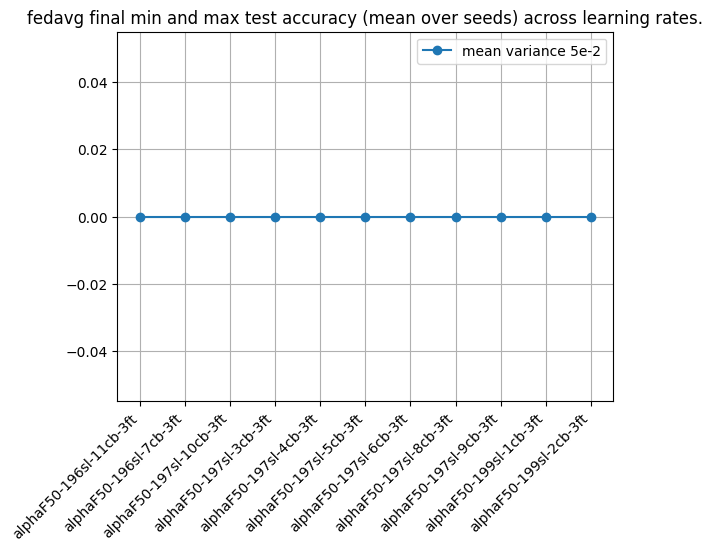

In [56]:
tmp_lr = tmp[['algorithm', 'availability', 'lr', 'mean_var_test_acc']]
display(tmp_lr)

x_values = [a.replace('gp-','').replace('-10ft', '') for a in tmp_lr.loc[(tmp_lr.lr==lrs[0])&(tmp_lr.algorithm=='fedavg'),'availability']]
for algo in ['fedavg']:
    plt.figure()

    for lr in lrs:
        plt.plot(x_values, tmp_lr[(tmp_lr.lr==lr)&(tmp_lr.algorithm==algo)]['mean_var_test_acc'], '-o', label='mean variance '+lr)

    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.title(algo+' final min and max test accuracy (mean over seeds) across learning rates.')
    plt.grid()

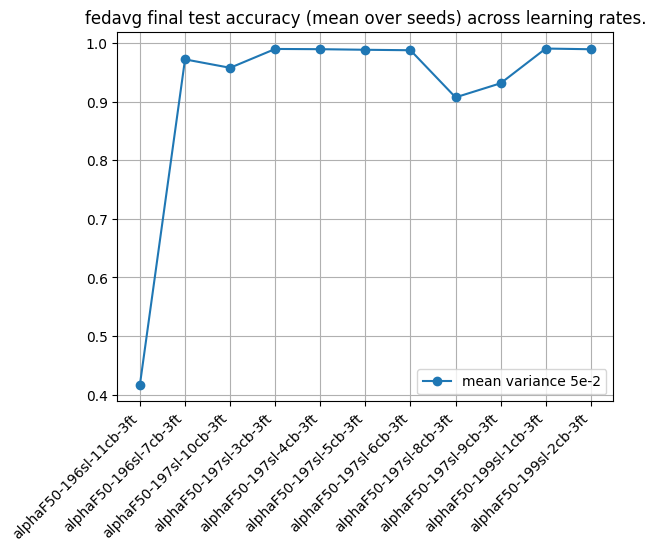

In [57]:
tmp_lr = tmp[['algorithm', 'availability', 'lr', 'final_mean_acc']]

x_values = [a.replace('gp-','').replace('-10ft', '') for a in tmp_lr.loc[(tmp_lr.lr==lrs[0])&(tmp_lr.algorithm=='fedavg'),'availability']]
for algo in ['fedavg']:
    plt.figure()

    for lr in lrs:
        plt.plot(x_values, tmp_lr[(tmp_lr.lr==lr)&(tmp_lr.algorithm==algo)]['final_mean_acc'], '-o', label='mean variance '+lr)

    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.title(algo+' final test accuracy (mean over seeds) across learning rates.')
    plt.grid()

In [58]:
res_old = tmp.loc[tmp.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmax()]

In [59]:
max_res = tmp.loc[tmp.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmax()][['algorithm','availability','final_mean_acc']].rename(columns={'final_mean_acc': 'max_final_mean_acc'})
min_res = tmp.loc[tmp.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmin()][['algorithm','availability','final_mean_acc']].rename(columns={'final_mean_acc': 'min_final_mean_acc'})

In [60]:
res_ = pd.merge(max_res, min_res, on=['algorithm', 'availability'], how='outer')

In [61]:
res_

,algorithm,availability,max_final_mean_acc,min_final_mean_acc
0,fedavg,alphaF50-196sl-11cb-3ft,0.4171,0.4171
1,fedavg,alphaF50-196sl-7cb-3ft,0.9726,0.9726
2,fedavg,alphaF50-197sl-10cb-3ft,0.9582,0.9582
3,fedavg,alphaF50-197sl-3cb-3ft,0.9904,0.9904
4,fedavg,alphaF50-197sl-4cb-3ft,0.9900,0.9900
5,fedavg,alphaF50-197sl-5cb-3ft,0.9890,0.9890
6,fedavg,alphaF50-197sl-6cb-3ft,0.9882,0.9882
7,fedavg,alphaF50-197sl-8cb-3ft,0.9077,0.9077
8,fedavg,alphaF50-197sl-9cb-3ft,0.9318,0.9318
9,fedavg,alphaF50-199sl-1cb-3ft,0.9911,0.9911


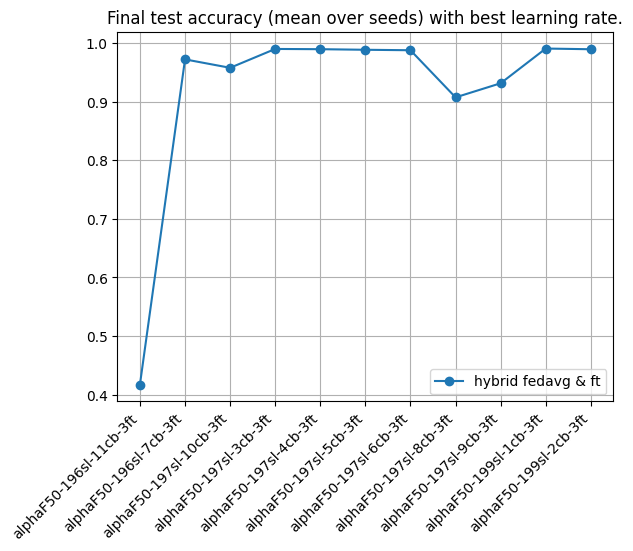

In [62]:
x_values = [a.replace('gp-','').replace('-10ft', '') for a in res_[res_.algorithm=='fedavg']['availability']]

plt.figure()
plt.plot(x_values, res_[res_.algorithm=='fedavg']['max_final_mean_acc'], '-o', label='hybrid fedavg & ft')
# plt.plot(x_values, res_[res_.algorithm=='fedvarp']['max_final_mean_acc'], '-o', label='hybrid fedvarp & ft')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title('Final test accuracy (mean over seeds) with best learning rate.')
plt.grid()

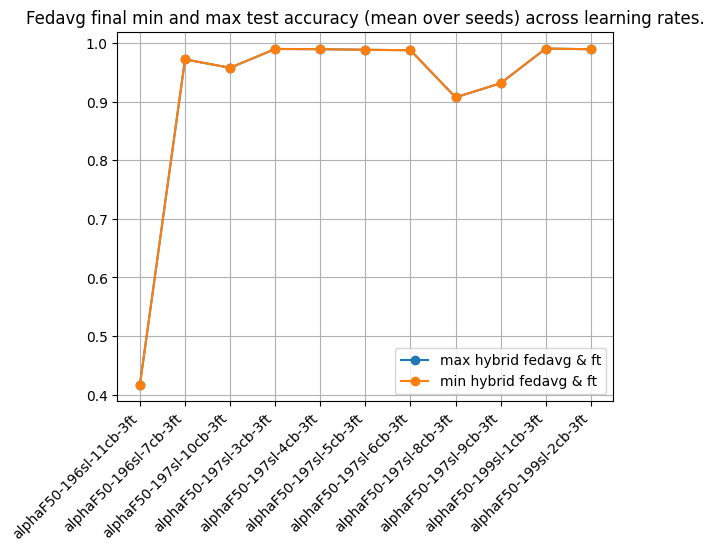

: 

In [63]:
plt.figure()
plt.plot(x_values, res_[res_.algorithm=='fedavg']['max_final_mean_acc'], '-o', label='max hybrid fedavg & ft')
plt.plot(x_values, res_[res_.algorithm=='fedavg']['min_final_mean_acc'], '-o', label='min hybrid fedavg & ft')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title('Fedavg final min and max test accuracy (mean over seeds) across learning rates.')
plt.grid()